In [25]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

## Feature Size

In [26]:
IF_9_1 = pd.read_csv("ClassImbalance_Diamonds/IF_9_1_class.csv")
IF_8_2 = pd.read_csv("ClassImbalance_Diamonds/IF_8_2_class.csv")
IF_7_3 = pd.read_csv("ClassImbalance_Diamonds/IF_7_3_class.csv")
IF_6_4 = pd.read_csv("ClassImbalance_Diamonds/IF_6_4_class.csv")
IF_5_5 = pd.read_csv("ClassImbalance_Diamonds/IF_5_5_class.csv")

TC_9_1 = pd.read_csv("ClassImbalance_Diamonds/TC_9_1_class.csv")
TC_8_2 = pd.read_csv("ClassImbalance_Diamonds/TC_8_2_class.csv")
TC_7_3 = pd.read_csv("ClassImbalance_Diamonds/TC_7_3_class.csv")
TC_6_4 = pd.read_csv("ClassImbalance_Diamonds/TC_6_4_class.csv")
TC_5_5 = pd.read_csv("ClassImbalance_Diamonds/TC_5_5_class.csv")

Label_1 = pd.read_csv("ClassImbalance_Diamonds/9_1_class_labelIDs.csv")
Label_2 = pd.read_csv("ClassImbalance_Diamonds/8_2_class_labelIDs.csv")
Label_3 = pd.read_csv("ClassImbalance_Diamonds/7_3_class_labelIDs.csv")
Label_4 = pd.read_csv("ClassImbalance_Diamonds/6_4_class_labelIDs.csv")
Label_5 = pd.read_csv("ClassImbalance_Diamonds/5_5_class_labelIDs.csv")

In [27]:
sorted_IF_lists = [IF_9_1, IF_8_2,IF_7_3,IF_6_4,IF_5_5]
sorted_TC_lists = [TC_9_1, TC_8_2,TC_7_3,TC_6_4,TC_5_5]
ratio=[(9,1),(8,2),(7,3),(6,4),(5,5)]
sorted_label_lists = [Label_1,Label_2,Label_3,Label_4,Label_5]
num_lists = len(sorted_IF_lists)
random_selection_rate = [0.1, 0.2, 0.3, 0.4, 0.5]

In [28]:
K = 200

In [29]:
def compute_sign_aware_lift(
    influence_df,
    label_df,
    minority_rate,
    k=100,
    score_col="Score"
):
    """
    Compute minority lift in:
      1. top-k signed influence scores,
      2. bottom-k signed influence scores,
      3. top-k absolute influence scores.

    Lift = minority proportion in selected set
           -----------------------------------
           minority proportion in full training set
    """

    ranked = influence_df.merge(
        label_df,
        left_on="Train_ID",
        right_on="id",
        how="left",
        validate="one_to_one"
    )

    ranked = ranked.drop(columns=["id"])

    if ranked["label"].isna().any():
        missing = ranked["label"].isna().sum()
        raise ValueError(f"{missing} influence rows have no matching label.")

    if score_col not in ranked.columns:
        raise KeyError(
            f"Cannot find score column '{score_col}'. "
            f"Available columns: {ranked.columns.tolist()}"
        )

    if k > len(ranked):
        raise ValueError(
            f"k={k} exceeds the number of training samples ({len(ranked)})."
        )

    # Highest signed influence
    top_signed = ranked.nlargest(k, score_col)

    # Lowest, most negative signed influence
    bottom_signed = ranked.nsmallest(k, score_col)

    # Largest influence magnitude
    top_absolute = (
        ranked.assign(Abs_Score=ranked[score_col].abs())
        .nlargest(k, "Abs_Score")
    )

    top_rate = top_signed["label"].mean()
    bottom_rate = bottom_signed["label"].mean()
    abs_top_rate = top_absolute["label"].mean()

    return {
        "Lift@Top": top_rate / minority_rate,
        "Lift@Bottom": bottom_rate / minority_rate,
        "Lift@AbsTop": abs_top_rate / minority_rate,
        "Minority@Top": top_rate,
        "Minority@Bottom": bottom_rate,
        "Minority@AbsTop": abs_top_rate
    }

In [30]:
records = []

for i in range(num_lists):
    minority_rate = float(random_selection_rate[i])

    # FOIF
    if_result = compute_sign_aware_lift(
        influence_df=sorted_IF_lists[i],
        label_df=sorted_label_lists[i],
        minority_rate=minority_rate,
        k=K,
        score_col="Score"
    )

    records.append({
        "Dataset": r"Diamonds",
        "Method": "FOIF",
        "Ratio": f"{ratio[i][1]}:{ratio[i][0]}",
        "k": K,
        "Lift@Top": if_result["Lift@Top"],
        "Lift@Bottom": if_result["Lift@Bottom"],
        "Lift@AbsTop": if_result["Lift@AbsTop"]
    })

    # TracIn
    tc_result = compute_sign_aware_lift(
        influence_df=sorted_TC_lists[i],
        label_df=sorted_label_lists[i],
        minority_rate=minority_rate,
        k=K,
        score_col="Score"
    )

    records.append({
        "Dataset": r"Diamonds",
        "Method": "TracIn",
        "Ratio": f"{ratio[i][1]}:{ratio[i][0]}",
        "k": K,
        "Lift@Top": tc_result["Lift@Top"],
        "Lift@Bottom": tc_result["Lift@Bottom"],
        "Lift@AbsTop": tc_result["Lift@AbsTop"]
    })

sign_aware_lift_table = pd.DataFrame(records)

print(sign_aware_lift_table.round(3))

    Dataset  Method Ratio    k  Lift@Top  Lift@Bottom  Lift@AbsTop
0  Diamonds    FOIF   1:9  200     9.950        0.850        9.000
1  Diamonds  TracIn   1:9  200    10.000        0.000        6.850
2  Diamonds    FOIF   2:8  200     5.000        2.375        4.675
3  Diamonds  TracIn   2:8  200     5.000        0.450        4.475
4  Diamonds    FOIF   3:7  200     3.333        1.917        3.050
5  Diamonds  TracIn   3:7  200     3.333        0.533        2.900
6  Diamonds    FOIF   4:6  200     2.300        1.262        2.075
7  Diamonds  TracIn   4:6  200     2.500        0.650        1.938
8  Diamonds    FOIF   5:5  200     0.820        0.830        0.830
9  Diamonds  TracIn   5:5  200     0.000        1.960        0.670


In [31]:
table_1_9 = sign_aware_lift_table[
    sign_aware_lift_table["Ratio"] == "1:9"
].copy()

table_1_9 = table_1_9[
    [
        "Dataset",
        "Method",
        "Ratio",
        "Lift@Top",
        "Lift@Bottom",
        "Lift@AbsTop"
    ]
]

print(table_1_9.round(3))

    Dataset  Method Ratio  Lift@Top  Lift@Bottom  Lift@AbsTop
0  Diamonds    FOIF   1:9      9.95         0.85         9.00
1  Diamonds  TracIn   1:9     10.00         0.00         6.85


In [32]:
for i in range(num_lists):
    ranked = (sorted_TC_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]

    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    topk_tbl = pd.DataFrame({
        "k": Ks,
        "%1s_topk": topk_rates,
    })

    topk_tbl["lift@k"] = topk_tbl["%1s_topk"] / p_random

    topk_tbl["gain@k"] = topk_tbl["%1s_topk"] - p_random

    print(f"Run {i+1}  Ratio: {ratio[i]}  (random p={p_random:.4f})  top-k results:")
    print(topk_tbl)

Run 1  Ratio: (9, 1)  (random p=0.1000)  top-k results:
      k  %1s_topk     lift@k    gain@k
0    10  1.000000  10.000000  0.900000
1    20  1.000000  10.000000  0.900000
2    50  1.000000  10.000000  0.900000
3   100  1.000000  10.000000  0.900000
4   200  1.000000  10.000000  0.900000
5   400  1.000000  10.000000  0.900000
6   800  0.683750   6.837500  0.583750
7  1600  0.343125   3.431250  0.243125
8  3200  0.171563   1.715625  0.071563
Run 2  Ratio: (8, 2)  (random p=0.2000)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  5.000000  0.800000
1    20  1.000000  5.000000  0.800000
2    50  1.000000  5.000000  0.800000
3   100  1.000000  5.000000  0.800000
4   200  1.000000  5.000000  0.800000
5   400  1.000000  5.000000  0.800000
6   800  0.941250  4.706250  0.741250
7  1600  0.579375  2.896875  0.379375
8  3200  0.339687  1.698437  0.139687
Run 3  Ratio: (7, 3)  (random p=0.3000)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  3.333

In [33]:
records = [] 

for i in range(num_lists):
    ranked = (sorted_TC_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])   

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]
    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    lifts = [(r / p_random) if p_random > 0 else np.nan for r in topk_rates]

    for k, lift in zip(Ks, lifts):
        records.append({"ratio": ratio[i], "k": k, "lift": lift})

all_tbl = pd.DataFrame(records)

In [34]:
print(all_tbl)

     ratio     k       lift
0   (9, 1)    10  10.000000
1   (9, 1)    20  10.000000
2   (9, 1)    50  10.000000
3   (9, 1)   100  10.000000
4   (9, 1)   200  10.000000
5   (9, 1)   400  10.000000
6   (9, 1)   800   6.837500
7   (9, 1)  1600   3.431250
8   (9, 1)  3200   1.715625
9   (8, 2)    10   5.000000
10  (8, 2)    20   5.000000
11  (8, 2)    50   5.000000
12  (8, 2)   100   5.000000
13  (8, 2)   200   5.000000
14  (8, 2)   400   5.000000
15  (8, 2)   800   4.706250
16  (8, 2)  1600   2.896875
17  (8, 2)  3200   1.698437
18  (7, 3)    10   3.333333
19  (7, 3)    20   3.333333
20  (7, 3)    50   3.333333
21  (7, 3)   100   3.333333
22  (7, 3)   200   3.333333
23  (7, 3)   400   3.333333
24  (7, 3)   800   3.333333
25  (7, 3)  1600   3.081250
26  (7, 3)  3200   1.843750
27  (6, 4)    10   2.500000
28  (6, 4)    20   2.500000
29  (6, 4)    50   2.500000
30  (6, 4)   100   2.500000
31  (6, 4)   200   2.500000
32  (6, 4)   400   2.500000
33  (6, 4)   800   2.421875
34  (6, 4)  1600   1

In [35]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
all_tbl["ratio"] = pd.Categorical(all_tbl["ratio"], categories=ratio, ordered=True)

pivot_kx = all_tbl.pivot_table(index="k", columns="ratio", values="lift", aggfunc="mean")
pivot_rx = all_tbl.pivot_table(index="ratio", columns="k", values="lift", aggfunc="mean")
print(pivot_kx)

ratio     (9, 1)    (8, 2)    (7, 3)    (6, 4)   (5, 5)
k                                                      
10     10.000000  5.000000  3.333333  2.500000  0.00000
20     10.000000  5.000000  3.333333  2.500000  0.00000
50     10.000000  5.000000  3.333333  2.500000  0.00000
100    10.000000  5.000000  3.333333  2.500000  0.00000
200    10.000000  5.000000  3.333333  2.500000  0.00000
400    10.000000  5.000000  3.333333  2.500000  0.00000
800     6.837500  4.706250  3.333333  2.421875  0.00000
1600    3.431250  2.896875  3.081250  1.842187  0.00000
3200    1.715625  1.698437  1.843750  1.521875  0.17375


Plot 1: x axis is k, bars are ratio

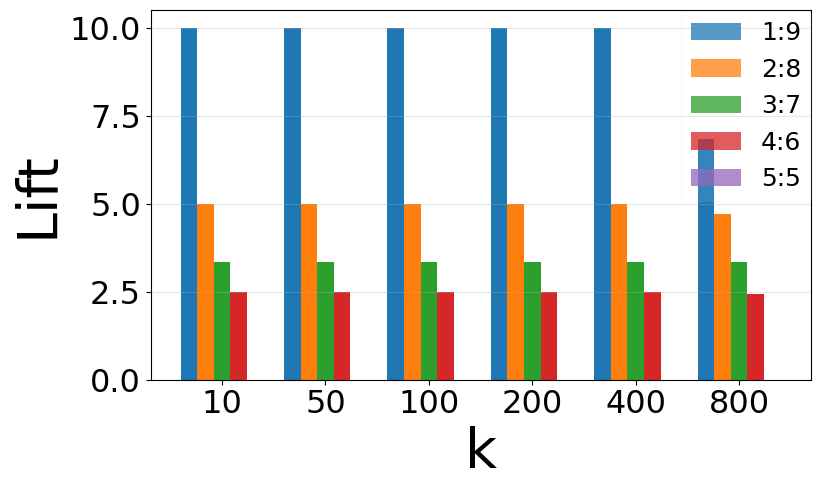

In [37]:
selected_K = [10, 50, 100, 200, 400, 800]

plot_df = pivot_kx.loc[selected_K]

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(plot_df.index))
n_groups = len(plot_df.columns)
bar_width = 0.8 / n_groups

for j, col in enumerate(plot_df.columns):
    ax.bar(
        x + j * bar_width - 0.4 + bar_width / 2,
        plot_df[col].values,
        width=bar_width,
        label=f"{col[1]}:{col[0]}" if isinstance(col, tuple) else str(col)
    )

ax.set_xlabel("k", fontsize=40)
ax.set_ylabel("Lift", fontsize=40)

# remove title
# ax.set_title(...)

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in plot_df.index], fontsize=23)
ax.tick_params(axis="y", labelsize=23)

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.02, 1.03),
    fontsize=18,
    framealpha=0.1
)

for h in legend.legend_handles:
    h.set_alpha(0.75)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Class_Imbalance_Diamonds_TC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()